In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/2625836599_03e192266f.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/16242239484_51286673af.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/5716633491_55e6f02645_n.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/13651218133_b6eb8e7ed2_m.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/8719032054_9a3ce4f0ff.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/9472854850_fc9e1db673.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/9293460423_7fbb1e3c32_n.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/9939430464_5f5861ebab.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/2535769822_513be6bbe9.jpg
/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion/8720503800_cab5c62

In [2]:
import numpy as np           
import pandas as pd          
import os                    
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential       
from tensorflow.keras.utils import to_categorical   
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import warnings
warnings.filterwarnings('ignore')

2026-03-29 11:48:50.584975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774784930.870681      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774784930.956802      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774784931.669061      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774784931.669110      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774784931.669114      17 computation_placer.cc:177] computation placer alr

In [3]:
labels= ['daisy',
 'dandelion',
 'roses',
 'sunflowers',
 'tulips']

In [4]:
img_path='/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos'

In [5]:
img_path

'/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos'

In [6]:
os.listdir('/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos') #os yani operation sistem programı klasör isimlerini verdi

['dandelion', 'sunflowers', 'daisy', 'roses', 'tulips']

In [7]:
import os
print(os.listdir('/kaggle/input'))
# alt klasörleri kontrol et
for d in os.listdir('/kaggle/input'):
    print(d, os.listdir(os.path.join('/kaggle/input', d)))

['datasets']
datasets ['rahmasleam']


In [8]:
for label in labels:
    folder = os.path.join(img_path, label)
    print("Checking:", folder)
    if not os.path.exists(folder):
        print("Not found:", folder)

Checking: /kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/daisy
Checking: /kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/dandelion
Checking: /kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/roses
Checking: /kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/sunflowers
Checking: /kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos/tulips


In [9]:
img_path = '/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos'
labels = ['daisy','dandelion','roses','sunflowers','tulips']  # alt klasör isimleri

img_list, label_list = [], []
for label in labels:
    folder = os.path.join(img_path, label)
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Klasör yok: {folder}")
    for img_file in os.listdir(folder):
        img_list.append(os.path.join(folder, img_file))
        label_list.append(label)

In [10]:
df=pd.DataFrame({'img':img_list,'label':label_list})

# EDA

In [11]:
df.head()

,img,label
0,/kaggle/input/datasets/rahmasleam/flowers-data...,daisy
1,/kaggle/input/datasets/rahmasleam/flowers-data...,daisy
2,/kaggle/input/datasets/rahmasleam/flowers-data...,daisy
3,/kaggle/input/datasets/rahmasleam/flowers-data...,daisy
4,/kaggle/input/datasets/rahmasleam/flowers-data...,daisy


In [12]:
d=({'daisy':0,
 'dandelion':1,
 'roses':2,
 'sunflowers':3,
 'tulips':4})

In [13]:
df['label_encoded']=df['label'].map(d)

In [14]:
df.sample(5)

,img,label,label_encoded
1564,/kaggle/input/datasets/rahmasleam/flowers-data...,roses,2
2370,/kaggle/input/datasets/rahmasleam/flowers-data...,sunflowers,3
776,/kaggle/input/datasets/rahmasleam/flowers-data...,dandelion,1
44,/kaggle/input/datasets/rahmasleam/flowers-data...,daisy,0
1055,/kaggle/input/datasets/rahmasleam/flowers-data...,dandelion,1


In [15]:
import seaborn as sns

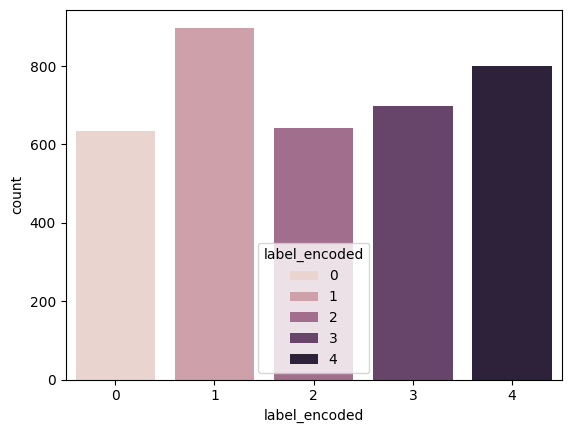

In [16]:
sns.countplot(x=df['label_encoded'], hue=df['label_encoded']);

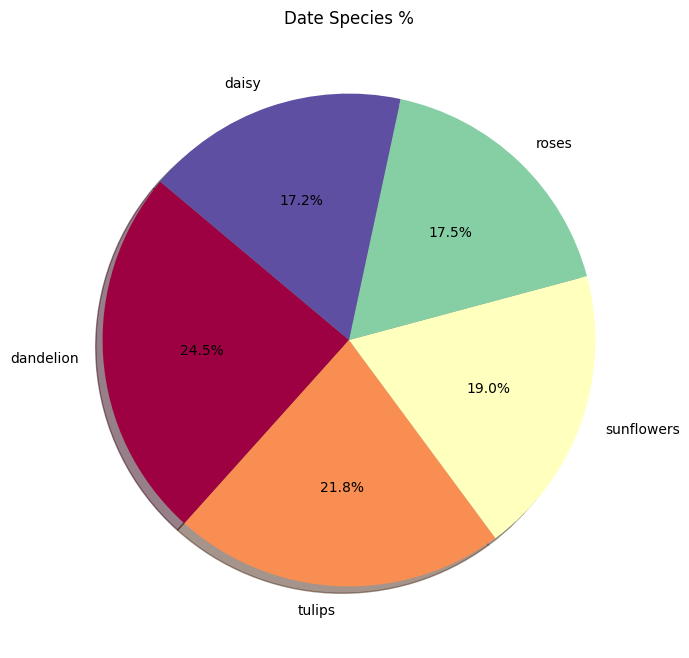

In [17]:
plt.figure(figsize=(10, 8))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', shadow=True, cmap='Spectral', startangle=140)
plt.title("Date Species %")
plt.ylabel('')
plt.show()

### Data Processing

In [18]:
x=[]
for img in df['img']:
    img=cv2.imread(str(img))
    img=cv2.resize(img,(32,32))
    img=img/255.0 #normalize ettik
    x.append(img)

In [19]:
x=np.array(x)

In [20]:
print(x.shape)

(3670, 32, 32, 3)


In [21]:
y=df[['label_encoded']]

# CNN Modeling

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42, test_size=0.10)

In [23]:
y_train=np.array(y_train)
y_test=np.array(y_test)

In [24]:
from keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, Reshape

In [25]:
model=Sequential()
model.add(Input(shape=(32, 32, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu')) # CNN
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu')) # CNN
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))  # Added activation function
model.add(Dense(5, activation='softmax'))  # Ensure 2 classes for binary classification

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

2026-03-29 11:49:49.035042: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [26]:
from tensorflow.keras.callbacks import EarlyStopping

In [27]:
early_stop=EarlyStopping(monitor='val_loss',patience=20)

In [28]:
history=model.fit(x_train,y_train, validation_data=(x_test,y_test), epochs=100, callbacks=[early_stop], verbose=1)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.3444 - loss: 1.4934 - val_accuracy: 0.5123 - val_loss: 1.1592
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5431 - loss: 1.1080 - val_accuracy: 0.5586 - val_loss: 1.0800
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6217 - loss: 0.9884 - val_accuracy: 0.6158 - val_loss: 0.9775
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6491 - loss: 0.9030 - val_accuracy: 0.6540 - val_loss: 0.9160
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6559 - loss: 0.8368 - val_accuracy: 0.6376 - val_loss: 0.9111
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6956 - loss: 0.7833 - val_accuracy: 0.6567 - val_loss: 0.8766
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7328 - loss: 0.7059 - val_accuracy: 0.6294 - val_loss: 0.9589
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7640 - loss: 0.6390 - 

In [29]:
model.save('flower_classificatin_model.h5')

In [30]:
model.save('flower_classificatin_model.keras')

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 945,233 (3.61 MB)

 Trainable params: 315,077 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 630,156 (2.40 MB)

### Model Interpretation

In [32]:
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential

In [33]:
data_dir='/kaggle/input/datasets/rahmasleam/flowers-dataset/flower_photos'
img_width,img_heigth=32,32
train_datagen=ImageDataGenerator(rescale=1/255, validation_split=0.10)
train_datagenerator=train_datagen.flow_from_directory(directory=data_dir,target_size=(img_width,img_heigth),
                                class_mode='categorical', subset='training')
test_datagen=ImageDataGenerator(rescale=1/255)
test_datagenerator=train_datagen.flow_from_directory(directory=data_dir,target_size=(img_width,img_heigth),
                                class_mode='categorical', subset='validation')

Found 3306 images belonging to 5 classes.
Found 364 images belonging to 5 classes.


In [34]:
from keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, Reshape

In [35]:
base_model=VGG16(weights='imagenet', input_shape=(img_width,img_heigth,3), include_top=False)
model=Sequential()
model.add(base_model)
for layer in base_model.layers:
    layer.trainable=False

model.add(Flatten())
model.add(Dense(1024,activation='relu'))
model.add(Dense(5,activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(train_datagenerator,epochs=100,callbacks=[early_stop],validation_data=test_datagenerator)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 217ms/step - accuracy: 0.4569 - loss: 1.2828 - val_accuracy: 0.6071 - val_loss: 1.0139
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.6312 - loss: 0.9454 - val_accuracy: 0.5962 - val_loss: 0.9709
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0.6733 - loss: 0.8498 - val_accuracy: 0.6429 - val_loss: 0.9009
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0.6914 - loss: 0.7721 - val_accuracy: 0.6484 - val_loss: 0.9186
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.7231 - loss: 0.7110 - val_accuracy: 0.6593 - val_loss: 0.8806
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - accuracy: 0.7488 - loss: 0.6500 - val_accuracy: 0.6648 - val_loss: 0.9120
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.7866 - loss: 0.5902 - val_accuracy: 0.6374 - val_loss: 1.0048
Epoch 8/100
104/104 ━━━━━

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,306,001 (62.20 MB)

 Trainable params: 530,437 (2.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 1,060,876 (4.05 MB)

In [37]:
model.save('flowers_TL.h5')

In [38]:
model.save('flowers_TL.keras')

In [39]:
import matplotlib.pyplot as plt

In [40]:
import numpy as np

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


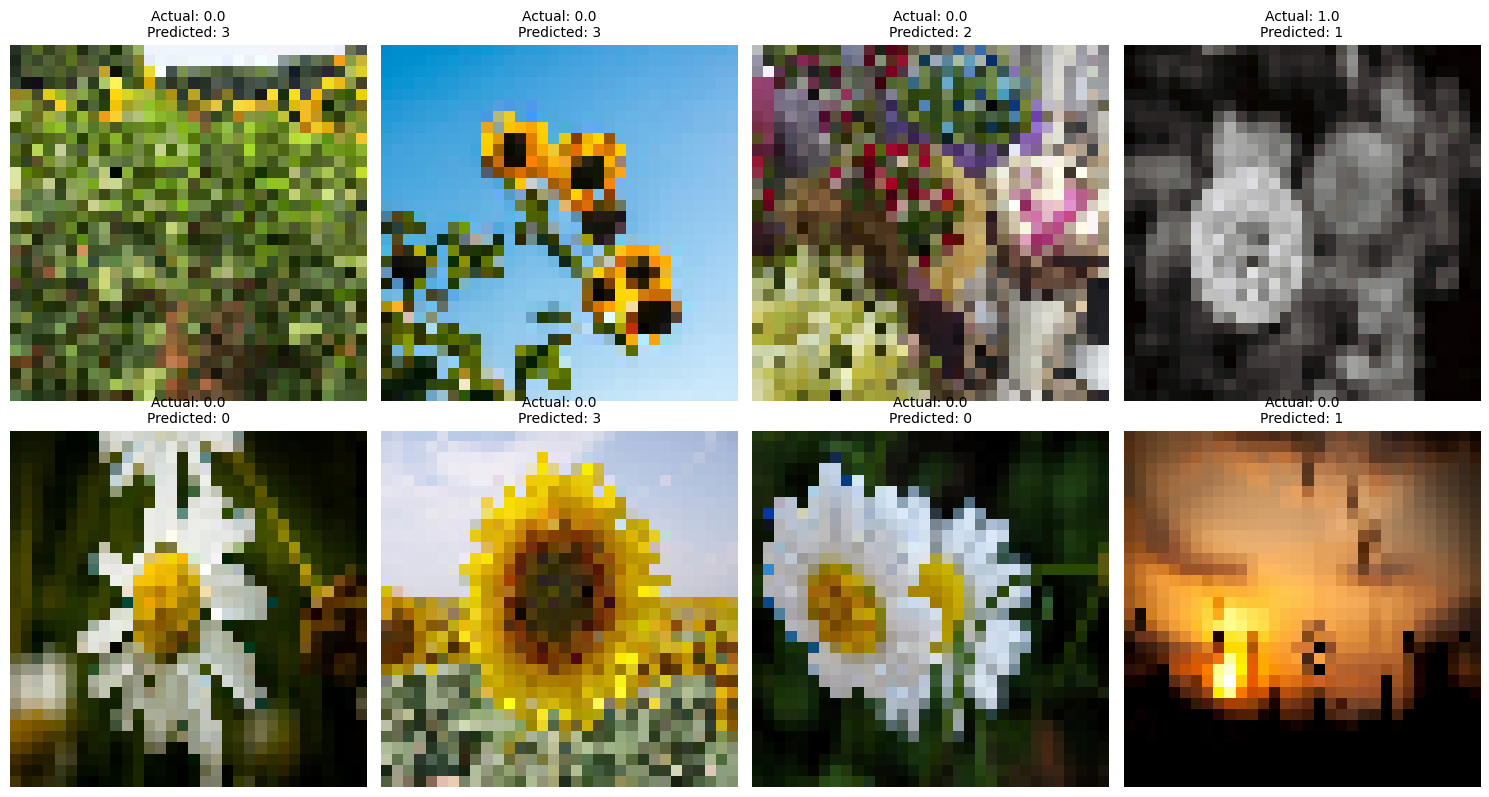

In [41]:
# Test verisi için toplam örnek sayısını alın
num_samples = test_datagenerator.samples  
batch_size = test_datagenerator.batch_size
num_batches = num_samples // batch_size

# Örnekleri almak için bir döngü kullanın
x_test_resized = []
actual_labels = []

# Rastgele batch'ler almak için döngü
for _ in range(min(8, num_batches)):
    # Rastgele bir batch seç
    batch_index = np.random.randint(num_batches)
    x, y = test_datagenerator[batch_index]  # Batch'i al

    for i in range(len(y)):
        if len(x_test_resized) < 8:  # 8 örnek almak için kontrol
            x_test_resized.append(x[i])  # Görüntüyü ekle
            actual_labels.append(y[i])  # Etiketi ekle
        else:
            break

x_test_resized = np.array(x_test_resized)
actual_labels = np.array(actual_labels).flatten()

# Model tahminleri
predictions = model.predict(np.array(x_test_resized))
predicted_labels = np.argmax(predictions, axis=1)

# Görselleştirme
plt.figure(figsize=(15, 8))
for i in range(len(x_test_resized)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_test_resized[i])
    plt.title(f"Actual: {actual_labels[i]}\nPredicted: {predicted_labels[i]}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()